In [1]:
# Insurance Claim Frequency Modeling using Poisson GLM
# This project builds a statistical model to predict insurance claim frequency using real-world policy data. The goal is to identify key risk drivers and improve model performance through feature engineering and variable selection.

In [2]:
## Modeling Approach

#A Poisson Generalized Linear Model (GLM) with a log link function was used to model claim counts. Exposure was incorporated as an offset to account for differences in policy duration. Feature engineering was applied to capture nonlinear relationships and handle skewed variables.

In [3]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
import statsmodels.api as sm
import matplotlib.pyplot as plt

In [4]:
## 1. Data Loading and Cleaning

In [5]:
df = pd.read_csv("freMTPL2freq.csv")
df = df[df["Exposure"] > 0]
df = df[df["ClaimNb"] >= 0]
df.shape
df.head()

,IDpol,ClaimNb,Exposure,VehPower,VehAge,DrivAge,BonusMalus,VehBrand,VehGas,Area,Density,Region
0,1.0,1,0.10,5,0,55,50,B12,Regular,D,1217,Rhone-Alpes
1,3.0,1,0.77,5,0,55,50,B12,Regular,D,1217,Rhone-Alpes
2,5.0,1,0.75,6,2,52,50,B12,Diesel,B,54,Picardie
3,10.0,1,0.09,7,0,46,50,B12,Diesel,B,76,Aquitaine
4,11.0,1,0.84,7,0,46,50,B12,Diesel,B,76,Aquitaine


In [6]:
## 2. Baseline Model
# A basic Poisson GLM using linear predictors.

In [7]:
baseline_model = smf.glm(
    formula="""
    ClaimNb ~ DrivAge + VehAge + VehPower 
              + BonusMalus 
              + Density
              + C(VehGas)
              + C(Area)
    """,
    data=df,
    family=sm.families.Poisson(),
    offset=np.log(df["Exposure"])
).fit()

print(baseline_model.summary())


                 Generalized Linear Model Regression Results                  
Dep. Variable:                ClaimNb   No. Observations:               678013
Model:                            GLM   Df Residuals:                   678001
Model Family:                 Poisson   Df Model:                           11
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -1.4345e+05
Date:                Thu, 23 Apr 2026   Deviance:                   2.1758e+05
Time:                        18:10:50   Pearson chi2:                 1.82e+06
No. Iterations:                     7   Pseudo R-squ. (CS):            0.01012
Covariance Type:            nonrobust                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept               -3.9300 

In [8]:
## The model includes an exposure offset to account for varying policy durations, allowing claim frequency to be modeled on a per-unit time basis.

In [9]:
## 3. Model Improvements
# Enhancements include nonlinear age effects and log-transformed density.

In [10]:
df["DrivAge2"] = df["DrivAge"]**2
df["log_Density"] = np.log(df["Density"] + 1)

In [11]:
## 4. Model after improvement

In [12]:
model2 = smf.glm(
    formula="""
    ClaimNb ~ DrivAge + DrivAge2
              + VehAge
              + VehPower
              + BonusMalus
              + log_Density
              + C(VehGas)
              + C(Area)
    """,
    data=df,
    family=sm.families.Poisson(),
    offset=np.log(df["Exposure"])
).fit()

print(model2.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                ClaimNb   No. Observations:               678013
Model:                            GLM   Df Residuals:                   678000
Model Family:                 Poisson   Df Model:                           12
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -1.4341e+05
Date:                Thu, 23 Apr 2026   Deviance:                   2.1751e+05
Time:                        18:10:53   Pearson chi2:                 1.81e+06
No. Iterations:                     7   Pseudo R-squ. (CS):            0.01023
Covariance Type:            nonrobust                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept               -4.4877 

In [13]:
## 5. Having Area as a predictor may be redundant (after adding density)
#    , so it may not be significant (since p-values for Area are quitehigh)
# , but we can check AIC to confirm.

In [14]:
model_no_area = smf.glm(
    formula="""
    ClaimNb ~ DrivAge + DrivAge2
              + VehAge
              + VehPower
              + BonusMalus
              + log_Density
              + C(VehGas)
    """,
    data=df,
    family=sm.families.Poisson(),
    offset=np.log(df["Exposure"])
).fit()
print(model_no_area.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                ClaimNb   No. Observations:               678013
Model:                            GLM   Df Residuals:                   678005
Model Family:                 Poisson   Df Model:                            7
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -1.4342e+05
Date:                Thu, 23 Apr 2026   Deviance:                   2.1752e+05
Time:                        18:10:55   Pearson chi2:                 1.82e+06
No. Iterations:                     7   Pseudo R-squ. (CS):            0.01022
Covariance Type:            nonrobust                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept               -4.4986 

In [15]:
print("Baseline AIC:", baseline_model.aic)
print("Improved Model AIC:", model2.aic)
print("Model without Area AIC:", model_no_area.aic)

Baseline AIC: 286928.89063004416
Improved Model AIC: 286855.34929348034
Model without Area AIC: 286854.6688530108


In [16]:
## 6. Based on the AIC values, the improved model improved AIC by approximately 73 points compared to the baseline, indicating a substantially better fit.
# However, the model with Area only has ~.68 which is essentially negligible, so area may indeed be redundant after adding density. 

In [17]:
## Final Interpretation
## Interpreting Coefficients - Because the model uses a log link function, coefficients are interpreted multiplicatively. For example, a coefficient of 0.07 corresponds to an increase of approximately e^0.07 ≈ 1.07, or a 7% increase in expected claim frequency.
# - BonusMalus is the strongest predictor of claim frequency, with each one-unit increase associated with approximately a 2.4% increase in expected claims  
# - Vehicle age is negatively associated with claims, with each additional year corresponding to approximately a 4.2% decrease in claim frequency  
# - Driver age exhibits a nonlinear relationship with risk, with claim frequency increasing at younger ages and peaking around age 60 before declining  
# - Vehicle power is a significant predictor, with each unit increase associated with approximately a 1.7% increase in claim frequency    
# - Fuel type has a discrete effect, with regular fuel vehicles associated with approximately 7% higher claim frequency than diesel vehicles  
# - Higher population density is associated with increased claim frequency, with each unit increase in log-density corresponding to approximately a 3.2% increase in expected claims  
# - Area may not add much predictive power after accounting for density, suggesting it may be redundant.

In [18]:
## Visualization: Predicted Risk by Driver Age

#This chart shows how predicted claim frequency changes with driver age while holding other variables fixed.

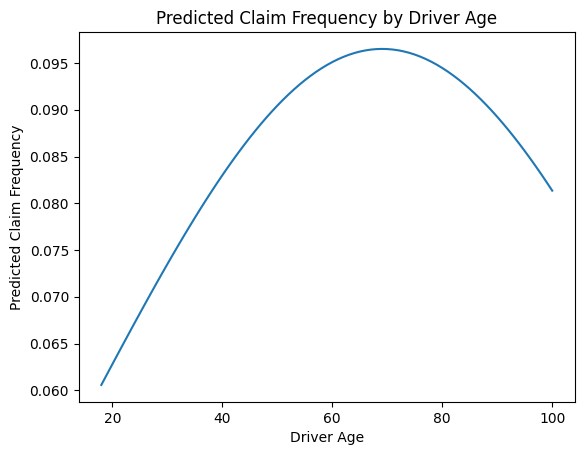

In [20]:
age_grid = pd.DataFrame({
    "DrivAge": range(int(df["DrivAge"].min()), int(df["DrivAge"].max()) + 1),
    "VehAge": df["VehAge"].median(),
    "VehPower": df["VehPower"].median(),
    "BonusMalus": df["BonusMalus"].median(),
    "log_Density": df["log_Density"].median(),
    "VehGas": df["VehGas"].mode()[0],
    "Exposure": 1
})

age_grid["DrivAge2"] = age_grid["DrivAge"]**2

age_grid["PredictedClaimFrequency"] = model_no_area.predict(
    age_grid,
    offset=np.log(age_grid["Exposure"])
)

plt.plot(age_grid["DrivAge"], age_grid["PredictedClaimFrequency"])
plt.xlabel("Driver Age")
plt.ylabel("Predicted Claim Frequency")
plt.title("Predicted Claim Frequency by Driver Age")
plt.show()

In [ ]:
## Appendix: Simulation to Understand Model Behavior

In [ ]:
np.random.seed(0)
n = 1000000
df = pd.DataFrame({
    "age": np.random.randint(18, 70, n),
    "vehicle_type": np.random.choice(["SUV", "sedan"], n),
    "past_claims": np.random.poisson(1, n),
    "exposure": np.random.uniform(0.5, 1.0, n)
})
df.head()

,age,vehicle_type,past_claims,exposure
0,62,SUV,1,0.946378
1,65,SUV,0,0.619819
2,18,SUV,2,0.619701
3,21,SUV,2,0.640733
4,21,SUV,2,0.816243


In [ ]:
beta_0 = -0.5
beta_age = -0.02
beta_past = 0.3
beta_sedan = -0.2

In [ ]:
vehicle_effect = (df["vehicle_type"] == "sedan") * beta_sedan
log_lambda = (
    beta_0
    + beta_age * df["age"]
    + beta_past * df["past_claims"]
    + vehicle_effect
)

In [ ]:
lambda_ = np.exp(log_lambda)
lambda_.head()

0    0.582748
1    0.223130
2    0.571209
3    0.537944
4    0.537944
dtype: float64

In [ ]:
df["claims"] = np.random.poisson(lambda_ * df["exposure"])
df.head()

,age,vehicle_type,past_claims,exposure,claims
0,62,SUV,4,0.895758,1
1,65,SUV,1,0.892320,0
2,18,SUV,1,0.989315,1
3,21,SUV,1,0.709842,1
4,21,SUV,1,0.943583,0


In [ ]:
model = smf.glm(
    formula="claims ~ age + past_claims + C(vehicle_type)",
    data=df,
    family=sm.families.Poisson(),
    offset=np.log(df["exposure"])
).fit()

print(model.summary())


                 Generalized Linear Model Regression Results                  
Dep. Variable:                 claims   No. Observations:                 1000
Model:                            GLM   Df Residuals:                      996
Model Family:                 Poisson   Df Model:                            3
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -663.03
Date:                Thu, 23 Apr 2026   Deviance:                       781.92
Time:                        16:32:59   Pearson chi2:                     964.
No. Iterations:                     5   Pseudo R-squ. (CS):            0.05885
Covariance Type:            nonrobust                                         
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept               